In [1]:
import xarray as xr
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image
import glob
import re
import json
import pandas as pd
from datetime import datetime
import matplotlib.colors as mcolors

## Processing SST Data

### Pure SST Data

Check file content here:

In [21]:
FILEPATH = "/Users/lina/Documents/DSC106/final_proj/data/AQUA_MODIS.20030101_20030131.L3m.MO.SST.sst.9km.nc"

ds = xr.open_dataset(FILEPATH)
print(ds)

<xarray.Dataset> Size: 75MB
Dimensions:   (lat: 2160, lon: 4320, rgb: 3, eightbitcolor: 256)
Coordinates:
  * lat       (lat) float32 9kB 89.96 89.88 89.79 89.71 ... -89.79 -89.88 -89.96
  * lon       (lon) float32 17kB -180.0 -179.9 -179.8 ... 179.8 179.9 180.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    sst       (lat, lon) float32 37MB ...
    qual_sst  (lat, lon) float32 37MB ...
    palette   (rgb, eightbitcolor) uint8 768B ...
Attributes: (12/61)
    product_name:                     AQUA_MODIS.20030101_20030131.L3m.MO.SST...
    instrument:                       MODIS
    title:                            MODISA Level-3 Standard Mapped Image
    project:                          Ocean Biology Processing Group (NASA/GS...
    platform:                         Aqua
    temporal_range:                   month
    ...                               ...
    cdm_data_type:                    grid
    keywords:                         Earth Science > Oceans > 

process one file first:

In [2]:
# === CONFIGURATION ===

# Where your raw MODIS files live on your local machine
DATA_DIR = "/Users/lina/Documents/DSC106/final_proj/data"

# Where to write processed PNGs — this should be inside your repo's data/ folder
OUTPUT_DIR = "/Users/lina/Documents/DSC106/final_proj/dsc106-final-project/docs/modis_data"

# The GBR bounding box (must match GBR_BBOX in global.js)
GBR_BBOX = {
    "lon_min": 142,
    "lon_max": 154,
    "lat_min": -24.5,
    "lat_max": -10,
}

# Temperature range for the colormap (in Celsius).
# 22–32°C covers GBR conditions; pixels outside this range will be clipped to the endpoints.
SST_MIN = 22.0
SST_MAX = 32.0

# Ensure output dir exists
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [3]:
def process_one_file(filepath, output_filename):
    """
    Open one monthly MODIS SST NetCDF, subset to GBR, mask poor-quality pixels,
    and save as a PNG with transparent background where no data.
    """
    ds = xr.open_dataset(filepath)

    # 1. Subset to GBR bounding box.
    # MODIS lats run high→low (89.96 down to -89.96), so we slice from high to low
    sst = ds["sst"].sel(
        lat=slice(GBR_BBOX["lat_max"], GBR_BBOX["lat_min"]),
        lon=slice(GBR_BBOX["lon_min"], GBR_BBOX["lon_max"]),
    )
    qual = ds["qual_sst"].sel(
        lat=slice(GBR_BBOX["lat_max"], GBR_BBOX["lat_min"]),
        lon=slice(GBR_BBOX["lon_min"], GBR_BBOX["lon_max"]),
    )

    # 2. Mask out poor-quality pixels.
    # MODIS quality flags: 0=best, 1=good, 2=questionable, 3=bad, 4=missing
    # Keep only quality 0 or 1
    sst_clean = sst.where(qual <= 2)

    # 3. Convert to numpy array (this is now lat x lon = ~170 x 140 for GBR)
    arr = sst_clean.values

    # 4. Normalize to [0, 1] for the colormap, masking NaN (land + cloud + bad quality)
    arr_norm = np.clip((arr - SST_MIN) / (SST_MAX - SST_MIN), 0, 1)
    mask = np.isnan(arr)  # True where there's no data

    # 5. Apply colormap.
    # "inferno" goes black→purple→red→yellow — good for absolute SST
    # We'll use this for baseline; later we'll use a diverging cmap for anomalies
    cmap = cm.get_cmap("inferno")
    rgba = cmap(arr_norm)  # shape (lat, lon, 4) of floats in [0, 1]

    # 6. Set alpha to 0 where data is missing (transparent on land/clouds)
    rgba[..., 3] = np.where(mask, 0, 1)

    # 7. Convert floats [0,1] → uint8 [0,255] and save as PNG
    rgba_uint8 = (rgba * 255).astype(np.uint8)
    img = Image.fromarray(rgba_uint8, mode="RGBA")

    output_path = os.path.join(OUTPUT_DIR, output_filename)
    img.save(output_path, optimize=True)

    # Also return some stats so we can verify
    return {
        "filepath": output_path,
        "shape": arr.shape,
        "mean_sst": float(np.nanmean(arr)),
        "min_sst": float(np.nanmin(arr)),
        "max_sst": float(np.nanmax(arr)),
        "pct_valid": float((~mask).sum() / mask.size * 100),
    }

In [24]:
# test one file
test_file = os.path.join(
    DATA_DIR,
    "AQUA_MODIS.20030101_20030131.L3m.MO.SST.sst.9km.nc"
)

result = process_one_file(test_file, "test_2003_01.png")
print(result)

{'filepath': '/Users/lina/Documents/DSC106/final_proj/dsc106-final-project/docs/modis_data/test_2003_01.png', 'shape': (174, 144), 'mean_sst': 28.616729736328125, 'min_sst': 25.969999313354492, 'max_sst': 33.5099983215332, 'pct_valid': 64.2440932311622}


/var/folders/mw/t_mvlctn6g10png8c08d_9g00000gn/T/ipykernel_70485/2672237852.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("inferno")


process all files:

In [4]:
def find_files_for_year(year):
    """
    Find all monthly MODIS files for a given year.
    Filename format: AQUA_MODIS.YYYYMMDD_YYYYMMDD.L3m.MO.SST.sst.9km.nc
    """
    pattern = os.path.join(DATA_DIR, f"AQUA_MODIS.{year}*.L3m.MO.SST.sst.9km.nc")
    files = sorted(glob.glob(pattern))
    return files

# Quick sanity check — how many files do you have for 2003?
files_2003 = find_files_for_year(2003)
print(f"2003: {len(files_2003)} files")
for f in files_2003[:3]:  # show first 3
    print(f"  {os.path.basename(f)}")

2003: 12 files
  AQUA_MODIS.20030101_20030131.L3m.MO.SST.sst.9km.nc
  AQUA_MODIS.20030201_20030228.L3m.MO.SST.sst.9km.nc
  AQUA_MODIS.20030301_20030331.L3m.MO.SST.sst.9km.nc


In [5]:
def process_one_year(year):
    """
    Average all monthly files for a year into one annual mean SST array,
    then save as a PNG.
    """
    files = find_files_for_year(year)
    if len(files) == 0:
        print(f"  ⚠ No files found for {year}")
        return None

    # Stack all monthly arrays
    monthly_arrays = []
    for filepath in files:
        ds = xr.open_dataset(filepath)
        sst = ds["sst"].sel(
            lat=slice(GBR_BBOX["lat_max"], GBR_BBOX["lat_min"]),
            lon=slice(GBR_BBOX["lon_min"], GBR_BBOX["lon_max"]),
        )
        qual = ds["qual_sst"].sel(
            lat=slice(GBR_BBOX["lat_max"], GBR_BBOX["lat_min"]),
            lon=slice(GBR_BBOX["lon_min"], GBR_BBOX["lon_max"]),
        )
        # Mask poor-quality pixels
        sst_clean = sst.where(qual <= 2)
        monthly_arrays.append(sst_clean.values)
        ds.close()  # important: release file handle

    # Stack into shape (n_months, lat, lon), then average over months ignoring NaN
    stacked = np.stack(monthly_arrays, axis=0)
    annual_mean = np.nanmean(stacked, axis=0)  # shape (lat, lon)

    # Render to PNG using the same logic as before
    mask = np.isnan(annual_mean)
    arr_norm = np.clip((annual_mean - SST_MIN) / (SST_MAX - SST_MIN), 0, 1)

    cmap = cm.get_cmap("inferno")
    rgba = cmap(arr_norm)
    rgba[..., 3] = np.where(mask, 0, 1)
    rgba_uint8 = (rgba * 255).astype(np.uint8)
    img = Image.fromarray(rgba_uint8, mode="RGBA")

    output_filename = f"sst_{year}.png"
    output_path = os.path.join(OUTPUT_DIR, output_filename)
    img.save(output_path, optimize=True)

    return {
        "year": year,
        "files_used": len(files),
        "mean_sst": float(np.nanmean(annual_mean)),
        "min_sst": float(np.nanmin(annual_mean)),
        "max_sst": float(np.nanmax(annual_mean)),
        "output": output_path,
    }

In [27]:
results = []
for year in range(2003, 2025):  # 2003 through 2024 inclusive
    print(f"Processing {year}...", end=" ", flush=True)
    result = process_one_year(year)
    if result:
        print(f"mean SST = {result['mean_sst']:.2f}°C, {result['files_used']} months")
        results.append(result)
    else:
        print("SKIPPED")

Processing 2003... mean SST = 26.87°C, 12 months
Processing 2004... 

/var/folders/mw/t_mvlctn6g10png8c08d_9g00000gn/T/ipykernel_70485/3670826947.py:30: RuntimeWarning: Mean of empty slice
  annual_mean = np.nanmean(stacked, axis=0)  # shape (lat, lon)
/var/folders/mw/t_mvlctn6g10png8c08d_9g00000gn/T/ipykernel_70485/3670826947.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("inferno")


mean SST = 26.84°C, 12 months
Processing 2005... 

/var/folders/mw/t_mvlctn6g10png8c08d_9g00000gn/T/ipykernel_70485/3670826947.py:30: RuntimeWarning: Mean of empty slice
  annual_mean = np.nanmean(stacked, axis=0)  # shape (lat, lon)
/var/folders/mw/t_mvlctn6g10png8c08d_9g00000gn/T/ipykernel_70485/3670826947.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("inferno")


mean SST = 26.96°C, 12 months
Processing 2006... 

...

/var/folders/mw/t_mvlctn6g10png8c08d_9g00000gn/T/ipykernel_70485/3670826947.py:30: RuntimeWarning: Mean of empty slice
  annual_mean = np.nanmean(stacked, axis=0)  # shape (lat, lon)
/var/folders/mw/t_mvlctn6g10png8c08d_9g00000gn/T/ipykernel_70485/3670826947.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("inferno")


mean SST = 27.63°C, 12 months
Processing 2022... 

/var/folders/mw/t_mvlctn6g10png8c08d_9g00000gn/T/ipykernel_70485/3670826947.py:30: RuntimeWarning: Mean of empty slice
  annual_mean = np.nanmean(stacked, axis=0)  # shape (lat, lon)
/var/folders/mw/t_mvlctn6g10png8c08d_9g00000gn/T/ipykernel_70485/3670826947.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("inferno")


mean SST = 27.81°C, 12 months
Processing 2023...   ⚠ No files found for 2023
SKIPPED
Processing 2024...   ⚠ No files found for 2024
SKIPPED


/var/folders/mw/t_mvlctn6g10png8c08d_9g00000gn/T/ipykernel_70485/3670826947.py:30: RuntimeWarning: Mean of empty slice
  annual_mean = np.nanmean(stacked, axis=0)  # shape (lat, lon)
/var/folders/mw/t_mvlctn6g10png8c08d_9g00000gn/T/ipykernel_70485/3670826947.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("inferno")


Saved metadata to /Users/lina/Documents/DSC106/final_proj/dsc106-final-project/docs/modis_data/sst_metadata.json



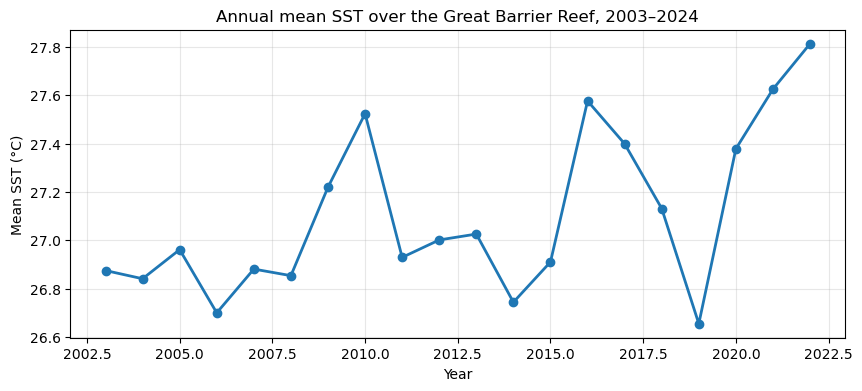

In [28]:
# Save metadata as a JSON sidecar — D3 will load this to know what data is available
metadata = {
    "bbox": GBR_BBOX,
    "sst_min": SST_MIN,
    "sst_max": SST_MAX,
    "years": [r["year"] for r in results],
    "yearly_stats": {
        r["year"]: {
            "mean_sst": round(r["mean_sst"], 2),
            "min_sst": round(r["min_sst"], 2),
            "max_sst": round(r["max_sst"], 2),
            "files_used": r["files_used"],
        }
        for r in results
    },
}

metadata_path = os.path.join(OUTPUT_DIR, "sst_metadata.json")
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Saved metadata to {metadata_path}")
print()

# Quick visualization of the trend
years = [r["year"] for r in results]
means = [r["mean_sst"] for r in results]

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(years, means, marker="o", linewidth=2)
plt.xlabel("Year")
plt.ylabel("Mean SST (°C)")
plt.title("Annual mean SST over the Great Barrier Reef, 2003–2024")
plt.grid(alpha=0.3)
plt.show()

### Anomaly SST Data

In [6]:
def compute_baseline(start_year=2003, end_year=2007):
    """
    Compute the mean SST across the baseline period.
    Returns a 2D array of the same shape as the GBR subset.
    """
    all_arrays = []
    for year in range(start_year, end_year + 1):
        files = find_files_for_year(year)
        for filepath in files:
            ds = xr.open_dataset(filepath)
            sst = ds["sst"].sel(
                lat=slice(GBR_BBOX["lat_max"], GBR_BBOX["lat_min"]),
                lon=slice(GBR_BBOX["lon_min"], GBR_BBOX["lon_max"]),
            )
            qual = ds["qual_sst"].sel(
                lat=slice(GBR_BBOX["lat_max"], GBR_BBOX["lat_min"]),
                lon=slice(GBR_BBOX["lon_min"], GBR_BBOX["lon_max"]),
            )
            sst_clean = sst.where(qual <= 2)
            all_arrays.append(sst_clean.values)
            ds.close()

    stacked = np.stack(all_arrays, axis=0)
    baseline = np.nanmean(stacked, axis=0)
    return baseline

print("Computing baseline (2003-2007)...")
baseline_sst = compute_baseline(2003, 2007)
print(f"  Baseline mean: {np.nanmean(baseline_sst):.2f}°C")
print(f"  Baseline shape: {baseline_sst.shape}")

Computing baseline (2003-2007)...
  Baseline mean: 26.85°C
  Baseline shape: (174, 144)


/var/folders/mw/t_mvlctn6g10png8c08d_9g00000gn/T/ipykernel_75409/995723387.py:24: RuntimeWarning: Mean of empty slice
  baseline = np.nanmean(stacked, axis=0)


In [7]:
# Anomaly color range — degrees C above/below baseline
ANOMALY_RANGE = 2.5  # ± this many degrees from baseline

def process_one_year_anomaly(year, baseline):
    """
    Compute annual mean SST anomaly (year_mean - baseline),
    save as PNG using a diverging colormap.
    """
    files = find_files_for_year(year)
    if len(files) == 0:
        print(f"  ⚠ No files found for {year}")
        return None

    monthly_arrays = []
    for filepath in files:
        ds = xr.open_dataset(filepath)
        sst = ds["sst"].sel(
            lat=slice(GBR_BBOX["lat_max"], GBR_BBOX["lat_min"]),
            lon=slice(GBR_BBOX["lon_min"], GBR_BBOX["lon_max"]),
        )
        qual = ds["qual_sst"].sel(
            lat=slice(GBR_BBOX["lat_max"], GBR_BBOX["lat_min"]),
            lon=slice(GBR_BBOX["lon_min"], GBR_BBOX["lon_max"]),
        )
        sst_clean = sst.where(qual <= 2)
        monthly_arrays.append(sst_clean.values)
        ds.close()

    stacked = np.stack(monthly_arrays, axis=0)
    annual_mean = np.nanmean(stacked, axis=0)
    anomaly = annual_mean - baseline  # pixel-wise difference

    mask = np.isnan(anomaly)
    # Normalize to [0, 1] where 0.5 = no anomaly, 0 = -ANOMALY_RANGE, 1 = +ANOMALY_RANGE
    arr_norm = np.clip((anomaly + ANOMALY_RANGE) / (2 * ANOMALY_RANGE), 0, 1)

    # RdBu_r: blue (cool) → white (no anomaly) → red (hot)
    cmap = plt.colormaps["RdBu_r"]
    rgba = cmap(arr_norm)
    rgba[..., 3] = np.where(mask, 0, 1)
    rgba_uint8 = (rgba * 255).astype(np.uint8)
    img = Image.fromarray(rgba_uint8, mode="RGBA")

    output_filename = f"anomaly_{year}.png"
    output_path = os.path.join(OUTPUT_DIR, output_filename)
    img.save(output_path, optimize=True)

    return {
        "year": year,
        "files_used": len(files),
        "mean_anomaly": float(np.nanmean(anomaly)),
        "min_anomaly": float(np.nanmin(anomaly)),
        "max_anomaly": float(np.nanmax(anomaly)),
        "output": output_path,
    }

In [31]:
anomaly_results = []
for year in range(2003, 2025):
    print(f"Processing anomaly {year}...", end=" ", flush=True)
    result = process_one_year_anomaly(year, baseline_sst)
    if result:
        sign = "+" if result["mean_anomaly"] >= 0 else ""
        print(f"mean anomaly = {sign}{result['mean_anomaly']:.2f}°C")
        anomaly_results.append(result)
    else:
        print("SKIPPED")

Processing anomaly 2003... mean anomaly = +0.02°C
Processing anomaly 2004... 

/var/folders/mw/t_mvlctn6g10png8c08d_9g00000gn/T/ipykernel_70485/185778142.py:30: RuntimeWarning: Mean of empty slice
  annual_mean = np.nanmean(stacked, axis=0)


mean anomaly = -0.01°C
Processing anomaly 2005... 

/var/folders/mw/t_mvlctn6g10png8c08d_9g00000gn/T/ipykernel_70485/185778142.py:30: RuntimeWarning: Mean of empty slice
  annual_mean = np.nanmean(stacked, axis=0)


mean anomaly = +0.11°C
Processing anomaly 2006... 

...

/var/folders/mw/t_mvlctn6g10png8c08d_9g00000gn/T/ipykernel_70485/185778142.py:30: RuntimeWarning: Mean of empty slice
  annual_mean = np.nanmean(stacked, axis=0)
/var/folders/mw/t_mvlctn6g10png8c08d_9g00000gn/T/ipykernel_70485/185778142.py:30: RuntimeWarning: Mean of empty slice
  annual_mean = np.nanmean(stacked, axis=0)


mean anomaly = +0.53°C
Processing anomaly 2021... mean anomaly = +0.77°C
Processing anomaly 2022... 

/var/folders/mw/t_mvlctn6g10png8c08d_9g00000gn/T/ipykernel_70485/185778142.py:30: RuntimeWarning: Mean of empty slice
  annual_mean = np.nanmean(stacked, axis=0)


mean anomaly = +0.94°C
Processing anomaly 2023...   ⚠ No files found for 2023
SKIPPED
Processing anomaly 2024...   ⚠ No files found for 2024
SKIPPED


/var/folders/mw/t_mvlctn6g10png8c08d_9g00000gn/T/ipykernel_70485/185778142.py:30: RuntimeWarning: Mean of empty slice
  annual_mean = np.nanmean(stacked, axis=0)


In [32]:
# Update the metadata with anomaly info
metadata["baseline_period"] = "2003-2007"
metadata["baseline_mean_sst"] = round(float(np.nanmean(baseline_sst)), 2)
metadata["anomaly_range"] = ANOMALY_RANGE
metadata["yearly_anomaly"] = {
    r["year"]: {
        "mean_anomaly": round(r["mean_anomaly"], 2),
        "min_anomaly": round(r["min_anomaly"], 2),
        "max_anomaly": round(r["max_anomaly"], 2),
    }
    for r in anomaly_results
}

# Re-save the metadata file
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Updated {metadata_path}")

Updated /Users/lina/Documents/DSC106/final_proj/dsc106-final-project/docs/modis_data/sst_metadata.json


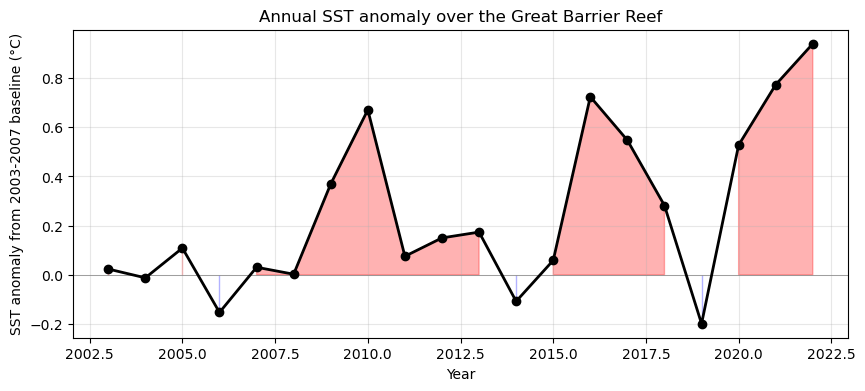

In [33]:
years = [r["year"] for r in anomaly_results]
anomalies = [r["mean_anomaly"] for r in anomaly_results]

plt.figure(figsize=(10, 4))
plt.axhline(0, color="gray", linewidth=0.5)  # baseline reference line
plt.fill_between(years, anomalies, 0,
                 where=[a >= 0 for a in anomalies], color="red", alpha=0.3)
plt.fill_between(years, anomalies, 0,
                 where=[a < 0 for a in anomalies], color="blue", alpha=0.3)
plt.plot(years, anomalies, marker="o", linewidth=2, color="black")
plt.xlabel("Year")
plt.ylabel("SST anomaly from 2003-2007 baseline (°C)")
plt.title("Annual SST anomaly over the Great Barrier Reef")
plt.grid(alpha=0.3)
plt.show()

### Per-pixel values

In [8]:
def save_pixel_data(arr, output_filename, value_type="sst"):
    """
    Save the per-pixel temperature array as JSON.
    NaN values (land/clouds) become null in JSON.
    
    The array shape is (lat, lon) with lat running high→low.
    """
    # Replace NaN with None so JSON can serialize it as null
    flat = arr.flatten()
    values = [None if np.isnan(v) else round(float(v), 2) for v in flat]
    
    payload = {
        "type": value_type,
        "shape": list(arr.shape),  # [n_lat, n_lon]
        "bbox": GBR_BBOX,
        "values": values,
    }
    
    output_path = os.path.join(OUTPUT_DIR, output_filename)
    with open(output_path, "w") as f:
        json.dump(payload, f)
    return output_path

In [11]:
print("Generating SST data + per-pixel JSON for each year...")
for year in range(2003, 2025):
    files = find_files_for_year(year)
    if len(files) == 0:
        continue
    
    monthly_arrays = []
    for filepath in files:
        ds = xr.open_dataset(filepath)
        sst = ds["sst"].sel(
            lat=slice(GBR_BBOX["lat_max"], GBR_BBOX["lat_min"]),
            lon=slice(GBR_BBOX["lon_min"], GBR_BBOX["lon_max"]),
        )
        qual = ds["qual_sst"].sel(
            lat=slice(GBR_BBOX["lat_max"], GBR_BBOX["lat_min"]),
            lon=slice(GBR_BBOX["lon_min"], GBR_BBOX["lon_max"]),
        )
        sst_clean = sst.where(qual <= 2)
        monthly_arrays.append(sst_clean.values)
        ds.close()
    
    stacked = np.stack(monthly_arrays, axis=0)
    annual_mean = np.nanmean(stacked, axis=0)
    anomaly = annual_mean - baseline_sst
    
    # Save per-pixel SST data
    save_pixel_data(annual_mean, f"sst_{year}.json", "sst")
    
    # Save per-pixel anomaly data
    save_pixel_data(anomaly, f"anomaly_{year}.json", "anomaly")
    
    print(f"  {year}: pixel data saved")

print("Done.")

Generating SST data + per-pixel JSON for each year...


/var/folders/mw/t_mvlctn6g10png8c08d_9g00000gn/T/ipykernel_73175/2341963884.py:23: RuntimeWarning: Mean of empty slice
  annual_mean = np.nanmean(stacked, axis=0)


  2003: pixel data saved


/var/folders/mw/t_mvlctn6g10png8c08d_9g00000gn/T/ipykernel_73175/2341963884.py:23: RuntimeWarning: Mean of empty slice
  annual_mean = np.nanmean(stacked, axis=0)


  2004: pixel data saved


...

/var/folders/mw/t_mvlctn6g10png8c08d_9g00000gn/T/ipykernel_73175/2341963884.py:23: RuntimeWarning: Mean of empty slice
  annual_mean = np.nanmean(stacked, axis=0)


  2020: pixel data saved


/var/folders/mw/t_mvlctn6g10png8c08d_9g00000gn/T/ipykernel_73175/2341963884.py:23: RuntimeWarning: Mean of empty slice
  annual_mean = np.nanmean(stacked, axis=0)


  2021: pixel data saved
  2022: pixel data saved
Done.


/var/folders/mw/t_mvlctn6g10png8c08d_9g00000gn/T/ipykernel_73175/2341963884.py:23: RuntimeWarning: Mean of empty slice
  annual_mean = np.nanmean(stacked, axis=0)


### SST and Coral Bleaching

In [9]:
# ============================================
# Extract 8-day SST at Cairns for 2016 and 2022
# ============================================

# Adjust if your 8-day files live in a different folder than monthly
DATA_DIR_8DAY = DATA_DIR  # change if separate, e.g. "/Users/.../modis_8day"

# Cairns area — central-northern GBR, where both events hit hardest
CAIRNS_LAT = -16.9
CAIRNS_LON = 145.9

# Bleaching threshold for the northern GBR (NOAA Coral Reef Watch standard)
# This is MMM (Maximum Monthly Mean from 1985-1993) + 1°C
BLEACHING_THRESHOLD = 29.7
MMM = 28.7

def extract_8day_sst(year, lat=CAIRNS_LAT, lon=CAIRNS_LON, window=0.5):
    """
    Find all 8-day files for a given year, extract mean SST at the target location,
    return list of {start_date, end_date, sst} for each 8-day period.
    """
    pattern = os.path.join(DATA_DIR_8DAY, f"AQUA_MODIS.{year}*.L3m.8D.SST.sst.*km.nc")
    files = sorted(glob.glob(pattern))
    
    if not files:
        print(f"  ⚠ No 8-day files found for {year}")
        return []
    
    series = []
    for filepath in files:
        # Parse start and end dates from filename
        basename = os.path.basename(filepath)
        # Format: AQUA_MODIS.YYYYMMDD_YYYYMMDD.L3m.8D...
        date_part = basename.split(".")[1]  # "YYYYMMDD_YYYYMMDD"
        start_str, end_str = date_part.split("_")
        start_date = datetime.strptime(start_str, "%Y%m%d")
        end_date = datetime.strptime(end_str, "%Y%m%d")
        # Use mid-period date for plotting (3-4 days into the 8-day window)
        mid_date = start_date + (end_date - start_date) / 2
        
        ds = xr.open_dataset(filepath)
        sst = ds["sst"].sel(
            lat=slice(lat + window, lat - window),
            lon=slice(lon - window, lon + window),
        )
        qual = ds["qual_sst"].sel(
            lat=slice(lat + window, lat - window),
            lon=slice(lon - window, lon + window),
        )
        sst_clean = sst.where(qual <= 2)
        mean_value = float(np.nanmean(sst_clean.values))
        ds.close()
        
        series.append({
            "date": mid_date.strftime("%Y-%m-%d"),
            "start_date": start_date.strftime("%Y-%m-%d"),
            "end_date": end_date.strftime("%Y-%m-%d"),
            "sst": round(mean_value, 2) if not np.isnan(mean_value) else None,
        })
    
    return series

# Extract for both years
print("Processing 2016...")
data_2016 = extract_8day_sst(2016)
print(f"  Got {len(data_2016)} 8-day windows")
for pt in data_2016[:3]:
    print(f"    {pt['date']}: {pt['sst']}°C")
print("  ...")

print("\nProcessing 2022...")
data_2022 = extract_8day_sst(2022)
print(f"  Got {len(data_2022)} 8-day windows")
for pt in data_2022[:3]:
    print(f"    {pt['date']}: {pt['sst']}°C")
print("  ...")

Processing 2016...
  Got 44 8-day windows
    2016-01-04: 30.19°C
    2016-01-12: 29.32°C
    2016-01-28: 29.84°C
  ...

Processing 2022...
  Got 45 8-day windows
    2022-01-04: 30.59°C
    2022-01-12: 30.06°C
    2022-01-20: 28.96°C
  ...


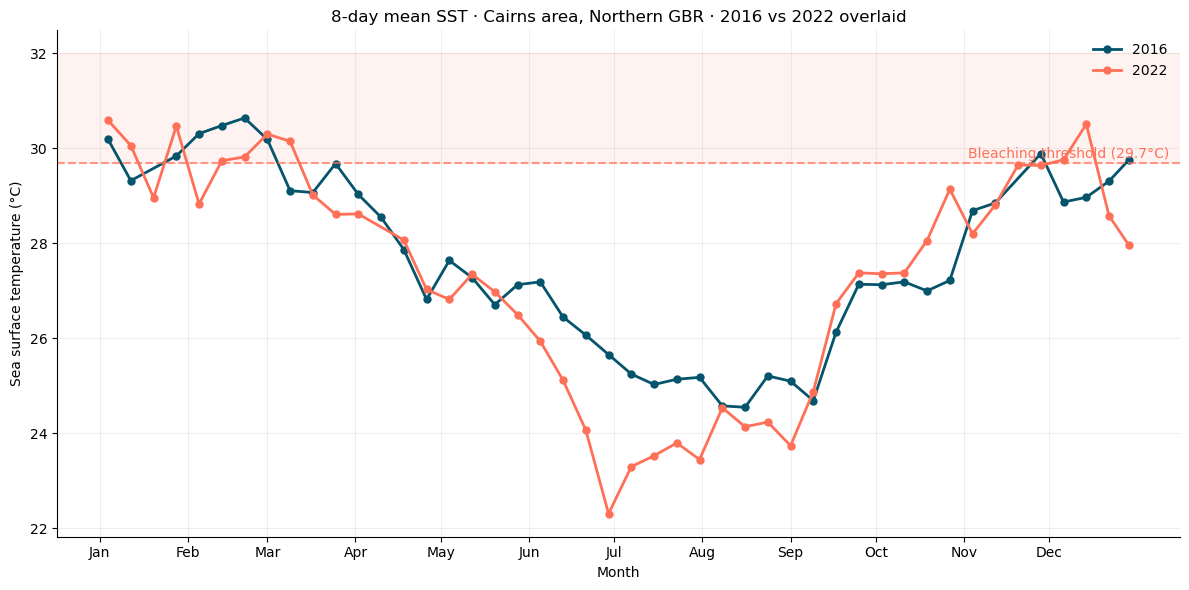

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))

# Plot both years aligned on a common "month-day" axis
for year_data, year_label, color in [
    (data_2016, "2016", "#04546b"),
    (data_2022, "2022", "#ff7058"),
]:
    # Convert dates to day-of-year so both years overlay
    day_of_year = [datetime.strptime(pt["date"], "%Y-%m-%d").timetuple().tm_yday for pt in year_data]
    ssts = [pt["sst"] for pt in year_data]
    ax.plot(day_of_year, ssts, marker="o", linewidth=2, color=color,
            label=year_label, markersize=5)

# Threshold + danger zone
ax.axhline(BLEACHING_THRESHOLD, linestyle="--", color="#ff7058", linewidth=1.5, alpha=0.7)
ax.axhspan(BLEACHING_THRESHOLD, 32, alpha=0.08, color="#ff7058")
ax.text(0.99, BLEACHING_THRESHOLD + 0.1, f"Bleaching threshold ({BLEACHING_THRESHOLD}°C)",
        color="#ff7058", transform=ax.get_yaxis_transform(),
        horizontalalignment="right", fontsize=10)

# Month labels on x-axis
month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
ax.set_xticks(month_starts)
ax.set_xticklabels(month_labels)

ax.set_xlabel("Month")
ax.set_ylabel("Sea surface temperature (°C)")
ax.set_title("8-day mean SST · Cairns area, Northern GBR · 2016 vs 2022 overlaid")
ax.legend(loc="upper right", frameon=False)
ax.grid(alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [11]:
output_path = os.path.join(OUTPUT_DIR, "bleaching_8day.json")
payload = {
    "location": {
        "name": "Cairns area, Northern GBR",
        "lat": CAIRNS_LAT,
        "lon": CAIRNS_LON,
    },
    "bleaching_threshold_c": BLEACHING_THRESHOLD,
    "mmm_c": MMM,
    "source": "NASA MODIS Aqua L3M 8-day SST · 4km",
    "events": {
        "2016": data_2016,
        "2022": data_2022,
    },
}
with open(output_path, "w") as f:
    json.dump(payload, f, indent=2)
print(f"\nSaved to {output_path}")
print(f"File size: {os.path.getsize(output_path) / 1024:.1f} KB")


Saved to /Users/lina/Documents/DSC106/final_proj/dsc106-final-project/docs/modis_data/bleaching_8day.json
File size: 12.2 KB


## Process Chlorophyll-a